# Chapter 7. Dimensionality Reduction

Dimensionality reduction refers to techniques that reduce the number of input features while preserving as much useful information as possible.

In many machine learning problems, datasets can contain a large number of features. While more features may seem helpful, high-dimensional data can make models slower, harder to visualize, and more prone to overfitting.

The main goal of dimensionality reduction is to simplify the dataset without losing the important structure of the data.

This chapter focuses on two major approaches:

Projection: reducing dimensions by projecting the data onto a lower-dimensional subspace.

Manifold Learning: reducing dimensions by assuming that high-dimensional data often lies near a lower-dimensional structure.

## The Curse of Dimensionality

The curse of dimensionality refers to the problems that occur when a dataset has too many features.

As the number of dimensions increases, the feature space grows extremely quickly. This makes the data increasingly sparse, meaning that training instances become farther apart from one another.

This can make it harder for machine learning models to find reliable patterns. It can also increase the risk of overfitting because the training data covers only a small portion of the entire feature space.

High-dimensional data can also make training slower and visualization more difficult.

Dimensionality reduction helps address these issues by reducing the number of features while trying to preserve the most important structure of the data.


## Main Approaches for Dimensionality Reduction

There are two main approaches to dimensionality reduction: projection and manifold learning.

Both methods try to reduce the number of dimensions while preserving the important structure of the data, but they do this in different ways.

### Projection

Projection reduces dimensionality by projecting high-dimensional data onto a lower-dimensional subspace.

For example, if a 3D dataset mostly lies near a 2D plane, we can project the data onto that plane without losing too much information.

This approach works well when the data has a roughly flat lower-dimensional structure.

### Manifold Learning

Manifold learning is based on the idea that high-dimensional data may lie near a lower-dimensional curved surface called a manifold.

In this case, simple projection may not preserve the structure of the data well.

Instead of projecting the data onto a flat subspace, manifold learning tries to uncover the underlying lower-dimensional shape of the data.

In short, projection is useful when the data lies near a flat lower-dimensional subspace, while manifold learning is useful when the data lies on a curved lower-dimensional structure.

## PCA

Principal Component Analysis, or PCA, is one of the most popular dimensionality reduction algorithms.

PCA first identifies the hyperplane that lies closest to the data, and then projects the data onto it.

The goal is to reduce dimensionality while losing as little information as possible.

### Preserving the Variance

When projecting high-dimensional data onto a lower-dimensional subspace, we want to preserve as much variance as possible.

Preserving variance is important because it helps keep the projected data spread out.

If we project the data onto the wrong axis, many points may become compressed together, causing a large loss of information.

### Principal Components

PCA identifies the directions that preserve the most variance in the dataset.

These directions are called principal components.

The first principal component captures the largest amount of variance. The second principal component captures the largest remaining variance while being orthogonal to the first component. The same idea continues for the remaining components.

We can find the principal components by centering the data and applying Singular Value Decomposition (SVD).

In [11]:
import numpy as np

# Create a small 3D dataset
rng = np.random.default_rng(seed=42)

m=60
x1 = rng.uniform(-1, 1, m)
x2 = rng.uniform(-1, 1, m)
noise = 0.1 * rng.standard_normal(m)

x3 = 2 * x1 + 0.5 * x2 + noise

X = np.c_[x1, x2, x3]

print("Dataset shape:", X.shape)

Dataset shape: (60, 3)


In [12]:
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

print('First principal component:\n', c1.round(3))
print('Second principal component:\n', c2.round(3))

First principal component:
 [-0.408 -0.156 -0.9  ]
Second principal component:
 [-0.268  0.962 -0.045]


### Projecting Down to d Dimensions

Once PCA identifies the principal components, we can reduce dimensionality by projecting the dataset onto the first $d$ principal components.

These components form a lower-dimensional subspace that preserves as much variance as possible. For example, projecting a 3D dataset onto the first two principal components reduces it to 2D while keeping the most important structure of the data.

In matrix form, this projection can be written as $$X_{\text{d-proj}} = X W_d$$, where $X$ is the original dataset, $W_d$ contains the first $d$ principal components, and $X_{\text{d-proj}}$ is the lower-dimensional representation of the data.

In [14]:
W2 = Vt[:2].T
X2D = X_centered @ W2

print('Projection matrix W2 shape:', W2.shape)
print('Projected shape:', X2D.shape)
print('\nFirst 5 projected instances:')
print(X2D[:5].round(3))

Projection matrix W2 shape: (3, 2)
Projected shape: (60, 2)

First 5 projected instances:
[[-1.5    0.169]
 [ 0.384  0.047]
 [-1.512 -0.074]
 [-1.151  0.412]
 [ 1.666  0.599]]


The original dataset has 3 features, so it is a 3D dataset.

After projecting it onto the first two principal components, the dataset becomes 2D.

The projection keeps the directions that preserve the most variance, while removing the least informative dimension.

### Using Scikit-Learn

Scikit-Learn provides a simple `PCA` class for applying Principal Component Analysis.

Instead of manually centering the data, applying SVD, and selecting principal components, we can use `PCA` directly.

The `n_components` hyperparameter controls the number of dimensions to keep.

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D_sklearn = pca.fit_transform(X)

print('Projected shape:', X2D_sklearn.shape)
print('\nFirst 5 projected instances:')
print(X2D_sklearn[:5].round(3))

Projected shape: (60, 2)

First 5 projected instances:
[[ 1.5    0.169]
 [-0.384  0.047]
 [ 1.512 -0.074]
 [ 1.151  0.412]
 [-1.666  0.599]]


This code reduces the original 3D dataset down to 2D using Scikit-Learn's `PCA`.  

The result is similar to the manual SVD projection, but the Scikit-Learn API is much simpler and more practical.

### Explained Variance Ratio 

The explained variance ratio tells us how much variance each principal component preserves.

This is useful because PCA components are ordered by importance. The first component preserves the most variance, the second component preserves the next largest amount, and so on.

In [20]:
pca.explained_variance_ratio_

array([0.87651792, 0.12249269])

The first principal component explains approximately 87.7% of the variance, and the second explains about 12.2%. 

Since the first two components together preserve nearly 99.9% of the total variance, reducing the data from 3D to 2D causes minimal information loss.

### Choosing the Right Number of Dimensions

Instead of choosing the number of dimensions manually, we can choose enough principal components to preserve a target amount of variance.  

A common choice is to preserve 95% of the variance. 

This allows PCA to decide how many dimensions are needed based on the structure of the data.

In [23]:
from sklearn.datasets import fetch_openml

# Load and split the MNIST dataset
mnist = fetch_openml("mnist_784", as_frame=False)

X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

print('Number of dimensions required to preserve 95% variance:', d)

Number of dimensions required to preserve 95% variance: 154


The cumulative explained variance tells us how much total variance is preserved as more principal components are added.

In the MNIST dataset, PCA can reduce the original 784 dimensions to far fewer dimensions while still preserving 95% of the variance.

In [25]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

print("Reduced training set shape:", X_reduced.shape)
print("Number of components selected:", pca.n_components_)

Reduced training set shape: (60000, 154)
Number of components selected: 154


Instead of manually setting `n_components` to an integer, we can set it to a float between 0 and 1.

When `n_components=0.95`, Scikit-Learn automatically keeps enough principal components to preserve 95% of the variance.

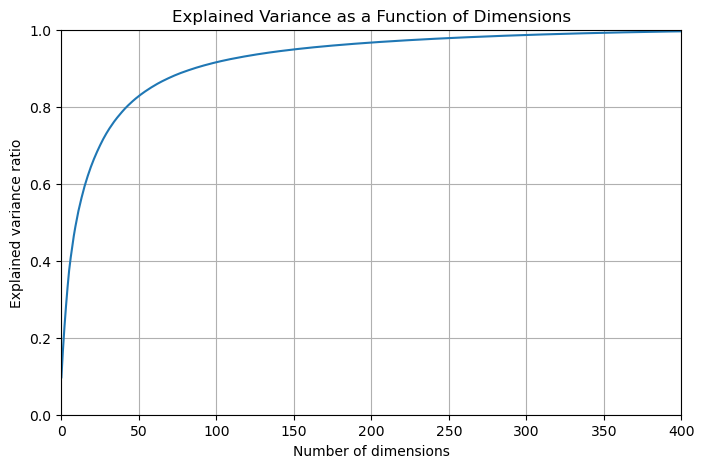

In [27]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 5)) 
plt.plot(cumsum)
plt.axis([0, 400, 0, 1])
plt.xlabel("Number of dimensions") 
plt.ylabel("Explained variance ratio") 
plt.title("Explained Variance as a Function of Dimensions")
plt.grid() 
plt.show()

The explained variance curve helps us choose a reasonable number of dimensions. 

A common strategy is to look for an elbow point, where adding more dimensions no longer increases the explained variance quickly.

### PCA as a Preprocessing Step

If dimensionality reduction is used before a supervised learning model, the number of PCA components can be tuned like any other hyperparameter.

For example, we can build a pipeline that first applies PCA and then trains a Random Forest classifier.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))

param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}

rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)

rnd_search.fit(X_train[:1000], y_train[:1000])

print("Best parameters:", rnd_search.best_params_)

Best parameters: {'randomforestclassifier__n_estimators': 475, 'pca__n_components': 57}


This pipeline treats the number of PCA components as a tunable hyperparameter. 

This is useful because the best number of dimensions depends on the downstream model and task.

### PCA for Compression
PCA can also be used for data compression. 

After reducing dimensionality, we can approximately reconstruct the original data using `inverse_transform()`. 

The difference between the original data and the reconstructed data is called the reconstruction error.

In [33]:
X_recovered = pca.inverse_transform(X_reduced)

print("Reduced shape:", X_reduced.shape)
print("Recovered shape:", X_recovered.shape)

Reduced shape: (60000, 154)
Recovered shape: (60000, 784)


The recovered dataset has the original number of features again. 

However, it is not exactly the same as the original dataset because PCA discarded some information during compression. 

If enough variance is preserved, the reconstruction can still remain close to the original data.

### Randomized PCA

Randomized PCA is a faster approximate version of PCA. 

When the target number of dimensions is much smaller than the original number of features, randomized PCA can be significantly faster than full SVD.

We can force Scikit-Learn to use randomized PCA by setting `svd_solver="randomized"`.

In [47]:
rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)

X_reduced = rnd_pca.fit_transform(X_train)

print("Reduced shape using randomized PCA:", X_reduced.shape)

Reduced shape using randomized PCA: (60000, 154)


Randomized PCA trades a small amount of precision for much faster computation. 

It is especially useful when the dataset has many features and we only need a much smaller number of principal components.

### Incremental PCA

Regular PCA requires the full training set to fit in memory.

Incremental PCA solves this problem by processing the training set in mini-batches.

This is useful for very large datasets or online learning settings where data arrives over time.

In [53]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)

for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

print("Reduced shape using Incremental PCA:", X_reduced.shape)

Reduced shape using Incremental PCA: (60000, 154)


Incremental PCA uses `partial_fit()` to learn from one mini-batch at a time.

This makes it possible to apply PCA even when the full dataset is too large to fit comfortably in memory.

### When PCA Becomes Too Slow

PCA is a powerful dimensionality reduction method, but it can become computationally expensive when the dataset has a very large number of features.

If a dataset has tens of thousands of features or more, such as high-dimensional images, text, or genomics data, even randomized PCA may become too slow or memory-intensive.

In this case, Random Projection can be a useful alternative.

## Random Projection
Random Projection is another dimensionality reduction technique.

Unlike PCA, it does not search for the directions that preserve the most variance. Instead, it projects the data onto a randomly chosen lower-dimensional space.

Surprisingly, if the target dimension is large enough, random projection can approximately preserve the distances between instances.

The key idea comes from the Johnson-Lindenstrauss lemma. 

It states that a high-dimensional dataset can be projected into a lower-dimensional space while approximately preserving pairwise distances, as long as the target dimension is large enough. 

The required target dimension depends mainly on the number of instances and the allowed distortion level.

In [62]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

m, epsilon = 5_000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=epsilon)

print('Minimum target dimension:', d)

Minimum target dimension: 7300


The epsilon value controls how much distortion we allow. 

A smaller epsilon means distances are preserved more accurately, but the required target dimension becomes larger. 

A larger epsilon allows more distortion, so fewer dimensions are needed.

Random Projection can be implemented by multiplying the original dataset by a randomly generated projection matrix. 

If the original dataset has shape $(m, n)$ and the random projection matrix has shape $(d, n)$, then multiplying by its transpose reduces the dataset to shape $(m, d)$.

In [70]:
n = 20_000

rng = np.random.default_rng(seed=42)

P = rng.standard_normal((d, n)) / np.sqrt(d) # Gaussian distribution with mean 0 and variance 1 / d
X = rng.standard_normal((m, n)) # generate a fake dataset

X_reduced = X @ P.T

print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)

Original shape: (5000, 20000)
Reduced shape: (5000, 7300)


The original fake dataset has $n$ features. 

After multiplying it by the transpose of the random projection matrix, the number of features is reduced to $d$. 

This shows the basic mechanism behind Random Projection.

### Gaussian Random Projection

Scikit-Learn provides `GaussianRandomProjection`, which performs the same type of projection automatically.

When it is fitted, it generates a random projection matrix and stores it in the `components_` attribute.

In [81]:
from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=epsilon, random_state=42)

X_reduced_gaussian = gaussian_rnd_proj.fit_transform(X) # same result as above

print("Reduced shape using GaussianRandomProjection:", X_reduced_gaussian.shape)

Reduced shape using GaussianRandomProjection: (5000, 7300)


`GaussianRandomProjection` automatically determines the target dimensionality using the Johnson-Lindenstrauss bound when `n_components` is not specified.

It is simple and efficient because it does not need to compute principal components.

### Sparse Random Projection

`SparseRandomProjection` is a more memory-efficient version of random projection.

It uses a sparse random projection matrix, meaning most values are zero. This reduces memory usage and can make projection faster for very high-dimensional or sparse datasets.

## LLE
Locally Linear Embedding, or LLE, is a nonlinear dimensionality reduction technique.

Unlike PCA and Random Projection, LLE does not project the data onto a flat lower-dimensional subspace. Instead, it tries to preserve the local geometric relationships between nearby instances.

This makes LLE useful for datasets that lie on a curved manifold, such as the Swiss roll dataset.

The main idea of LLE is based on local linearity.

First, for each instance, the algorithm finds its nearest neighbors. Then it tries to reconstruct each instance as a linear combination of those neighbors.

After that, LLE finds a lower-dimensional representation that preserves these local reconstruction relationships as much as possible.

In [97]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)

X_unrolled = lle.fit_transform(X_swiss)

print("Original shape:", X_swiss.shape)
print("Reduced shape:", X_unrolled.shape)

Original shape: (1000, 3)
Reduced shape: (1000, 2)


The Swiss roll dataset is originally 3D, but it has an underlying 2D manifold structure.

LLE reduces the dataset from 3D to 2D by trying to preserve local neighbor relationships.

This is different from PCA, which only looks for the directions that preserve the most variance.

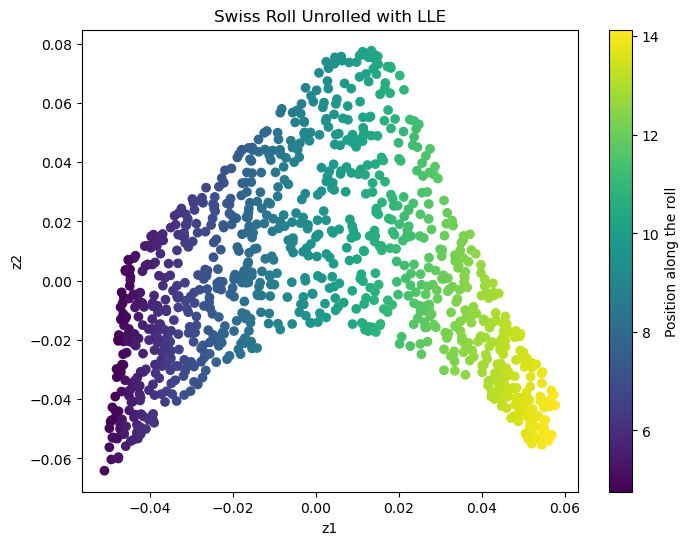

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_unrolled[:, 0], X_unrolled[:, 1], c=t, cmap="viridis")
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Swiss Roll Unrolled with LLE")
plt.colorbar(label="Position along the roll")
plt.show()

The color represents the position of each point along the original Swiss roll.

If LLE works well, points that were close to each other on the curved surface should remain close in the 2D representation.

This illustrates how manifold learning can recover nonlinear low-dimensional structure that PCA may fail to preserve.